<a href="https://colab.research.google.com/github/roldannahuelalejadro/Fisica-de-Fluidos-E1/blob/main/P4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema 4: Estimación de parámetros con PINNs**

Un grupo de Laboratorio 5 elige hacer la mejor práctica de la materia: Fluidos.
En esta práctica, se introduce un agitador magnético para generar un vórtice dentro de un recipiente cilíndrico y se usa el método velocimetría de imágenes de partículas (PIV, por sus siglas en inglés).
Esto permite medir el campo de velocidades $\mathbf{u}(\mathbf{x}, t)$ sobre la superficie, habitualmente modelado mediante el vórtice de Burgers
$$ \mathbf{u}_B(\mathbf{x}, t) = -\alpha r \mathbf{\hat{r}} + \frac{\Gamma}{2\pi r}\left[1 - \exp\left(-r^2/r_0^2\right)\right]\boldsymbol{\hat{\theta}} + 2\alpha z\mathbf{\hat{z}} $$

donde $\Gamma$ es la circulación asintótica del vórtice, $\alpha$ un parámetro que controla el flujo radial y $r_0 = \alpha / 2\nu$ un radio característico del vórtice controlado por la velocidad y la viscosidad.
Dado que se mira la superficie, la componente $z$ suele ignorarse por completo.

Sin embargo, las cámaras de alta velocidad necesarias para hacer PIV no funcionan y no pudieron ser reemplazadas por cuestiones presupuestarias. Ante la desesperación, el grupo decide introducir una pequeña bolita de polietileno dentro del flujo y grabarla con un celular.
Luego, el grupo elige algunos de los cuadros del video donde tanto el centro del vórtice cómo la bolita se ven claramente y, muy laboriosamente, determinan la posición relativa de ambos.
Estos datos se encuentran en el archivo `posiciones.txt`, con la posición $\mathbf{X}(t)$ (en cartesianas) de la boltia respecto al vórtice (que se considera en el origen) para los $t$ indicados. Las distancias están medidas en centimetros y el tiempo en segundos.

Entrene una PINN que ajuste la trayectoria mediante el modelo de Burgers $\dot{\mathbf{X}} = \mathbf{u}_B(\mathbf{X}, t)$ y aprenda los parámetros $\alpha$, $\Gamma$ y $r_0$. La predicción de la PINN debe coincidir con los datos provistos en una trayectoria aproximadamente espiralada, cómo mínimo. Puede usar el siguiente esqueleto, que además contiene estimaciones del orden de magnitud de los distintos parámetros hechos por el grupo. Los parámetros propuestos no son necesariamente óptimos, es libre de cambiarlos todos.

**Nota:** Por simplicidad, ignoraremos los errores en la medición de estos datos, pero podrían incluirse cómo un término adicional de la función de pérdida.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Cargar datos
!pip install -q gdown
!gdown 1USjbT0fCDREgM0KIFsn_9JCvcA7jBXuD -O posiciones.txt

t_data, x_data, y_data = np.loadtxt("posiciones.txt", unpack=True)



Downloading...
From: https://drive.google.com/uc?id=1USjbT0fCDREgM0KIFsn_9JCvcA7jBXuD
To: /content/posiciones.txt
100% 1.52k/1.52k [00:00<00:00, 6.60MB/s]


Voy a querer armarme una PINN que contenga dentro de su funcion de perdida fisica el modelo de vorticidad de Burgers, sin embargo el fordward necesario debe ser necesariamente los parametros a controlar, de modo que el sistema aprenda a "elejir" estos parametros

 Este problema es ligereamente distinto al resto, ya que se nos presenta una
serie de datos que son los que obtuvo el grupo de laboratorio expuestos en el archivo (archivo `posiciones.txt`), y usaremos la red neuronal para que ajuste los parámetros fisicos $(\alpha, \Gamma, r_0)$
uniendo los datos con trayectorias que satisfagan las ecuaciones diferenciales.
Comenzamos llamando las librerías necesarias y definiendo nuestra PINN a través de $classPINN$ reutilizando el esqueleto del código del punto anterior.
Como se comentó anteriormente, buscamos entrenar a nuestra red minimizando una funcion que llamamos la "funcion de perdida total" denotada por $\mathcal{L}$, la cual se define como:
 $$\mathcal{L} = \mathcal{L}_{\text{data}} + \lambda\,\mathcal{L}_{\text{phys}}$$

En éste caso nuestra entrada está definida por una neurona, que corresponde a la unica variable independiente, el **tiempo**. Se definió en la parte de ***"hidden sizes***" las capas ocultas, que estan compuestas por 3 etapas cada una con 32 neuronas las cuales son las que entrenaremos, y por ultimo contamos con la salida que es bidimensional con 2 neuronas que corresponden a las variables en polares ($r(t); \theta(t)$).

Luego viene una parte de crucial importancia, como mencionamos antes los parametros que queremos ajustar son $$(\alpha, \Gamma, r_0)$$ por lo tanto, estas cantidades **NO** deben estar igualadas a alguna cantidad ya que sino el codigo las contemplaría como fijas. Para este problema precisamente, buscamos variar estas cantidades para que se ajusten a nuestro modelo fisico descrito por las ecuaciones diferenciales. En el código se expresa entre cortchetes [] el valor inicial de estas cantidades en torno a las que el programa las ajustará.

### Explicación del enfoque con PINN

Por lo tanto en lugar de resolver una ecuación diferencial conocida, contamos con datos experimentales de la trayectoria de una bolita en un vórtice. El objetivo central de este trabajo es utilizar una **Physics-Informed Neural Network (PINN)** para ajustar simultáneamente la trayectoria observada $r(t)$ y $\theta(t)$ (coordenadas polares) y los parámetros físicos desconocidos del modelo del vórtice de Burgers: $\alpha$, $\Gamma$ y $r_0$. Y a su vez las derivadas temporales satisfagan las ecuaciones diferenciales del modelo de Burgers (pérdida física).

De esta forma, la red no solo interpola la trayectoria, sino que **aprende** los parámetros físicos que mejor explican el movimiento observado.

#### 1. Preparación de los datos

Primero cargamos los datos experimentales que contienen las posiciones $(x(t), y(t))$ de la bolita. Luego convertimos estas posiciones a coordenadas polares:
- $r(t) = \sqrt{x^2 + y^2}$
- $\theta(t) = arctan(y, x)$

Dado que la partícula realiza aproximadamente **2.5 revoluciones**, aplicamos `np.unwrap()` al ángulo para obtener un $\theta(t)$ continuo y creciente (sin saltos de $2\pi$).

Posteriormente, realizamos una **normalización** de las variables $t$, $r$ y $\theta$. Esto es fundamental para mejorar la estabilidad numérica y el balance entre las distintas escalas (el ángulo desenrollado alcanza valores mucho mayores que el radio).

#### 2. Definición de la PINN

Definimos la red neuronal a través de la clase `PINN`. La arquitectura es la siguiente:

- **Entrada**: 1 neurona correspondiente al tiempo $t$ (normalizado).
- **Capas ocultas**: 3 capas densas con 32 neuronas cada una, utilizando la función de activación $\tanh$.
- **Salida**: 2 neuronas que representan las variables normalizadas $r_{\text{norm}}(t)$ y $\theta_{\text{norm}}(t)$.

Los parámetros físicos que deseamos estimar ($\alpha$, $\Gamma$ y $r_0$) se definen como **parámetros entrenables** (`torch.nn.Parameter`). A diferencia de las redes convencionales, estos valores **no son fijos**: el optimizador los ajustará durante el entrenamiento junto con los pesos de la red. Se inicializan con valores razonables basados en estimaciones previas:
- $\alpha \approx 0.075$
- $\Gamma \approx 710$ (usamos $\log(\Gamma)$ para mantenerlo positivo)
- $r_0 \approx 0.60$

#### 3. Función de pérdida

La red se entrena minimizando la **función de pérdida total**:

$$
\mathcal{L} = \mathcal{L}_{\text{data}} + \lambda \, \mathcal{L}_{\text{phys}}
$$

donde:
- $\mathcal{L}_{\text{data}}$ mide el error cuadrático medio entre la predicción de la red y los datos normalizados de $(r, \theta)$.
- $\mathcal{L}_{\text{phys}}$ es el residual de las ecuaciones diferenciales del vórtice de Burgers. Se calcula utilizando `autograd` para obtener las derivadas $\frac{dr}{dt}$ y $\frac{d\theta}{dt}$ y compararlas con las expresiones teóricas:
  $$
  \frac{dr}{dt} = -\alpha r, \qquad \frac{d\theta}{dt} = \frac{\Gamma}{2\pi r^2} \left(1 - e^{-r^2/r_0^2}\right)
  $$

El factor $\lambda$ permite balancear la importancia relativa entre ajustarse a los datos y respetar la física.

#### 4. Entrenamiento

Durante el entrenamiento, la red aprende simultáneamente:
- A reproducir la trayectoria observada.
- A satisfacer las ecuaciones diferenciales del modelo.
- Los valores óptimos de los parámetros $\alpha$, $\Gamma$ y $r_0$.

Al finalizar, los valores obtenidos de estos parámetros representan la estimación física más consistente con los datos experimentales bajo el modelo de Burgers.


Normalización aplicada:
t     → mean=2.8517, std=1.7407
r     → mean=3.7114, std=0.1598
theta → mean=7.4771, std=4.7825

Epoch     0 | Total 1.11e+01 | Data 1.01e+00 | Phys 6.74e-01 | α=0.07440  Γ=50.0  r0=0.6000
Epoch  2000 | Total 3.63e-01 | Data 3.62e-01 | Phys 8.12e-05 | α=0.04298  Γ=60.7  r0=0.6000
Epoch  4000 | Total 2.22e-01 | Data 2.21e-01 | Phys 3.75e-05 | α=0.04324  Γ=137.1  r0=0.6000
Epoch  6000 | Total 2.80e-02 | Data 2.76e-02 | Phys 2.73e-05 | α=0.04325  Γ=314.5  r0=0.6000
Epoch  8000 | Total 1.67e-03 | Data 1.59e-03 | Phys 5.69e-06 | α=0.04317  Γ=389.2  r0=0.6000
Epoch 10000 | Total 2.55e-04 | Data 2.28e-04 | Phys 1.76e-06 | α=0.04314  Γ=406.6  r0=0.6000
Epoch 12000 | Total 1.90e-04 | Data 1.72e-04 | Phys 1.17e-06 | α=0.04314  Γ=410.1  r0=0.6000
Epoch 14000 | Total 1.81e-04 | Data 1.69e-04 | Phys 8.10e-07 | α=0.04314  Γ=410.8  r0=0.6000
Epoch 16000 | Total 1.79e-04 | Data 1.69e-04 | Phys 6.96e-07 | α=0.04314  Γ=410.9  r0=0.6000
Epoch 18000 | Total 3.35e-04 | Data 1.69e-04

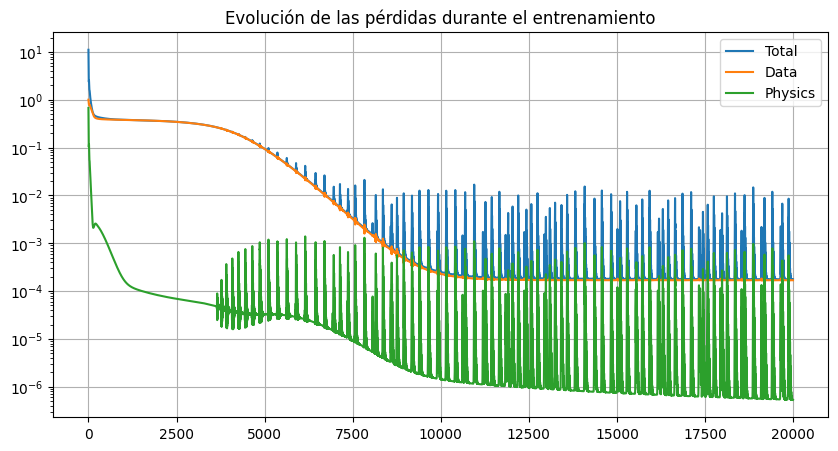

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ====================== DATOS ======================
t_data_np, x_data, y_data = np.loadtxt("posiciones.txt", unpack=True)

r_data = np.sqrt(x_data**2 + y_data**2)
theta_data = np.arctan2(y_data, x_data)
theta_unwrapped = np.unwrap(theta_data)

# ====================== NORMALIZACIÓN ======================
t_mean = t_data_np.mean()
t_std  = t_data_np.std()
r_mean = r_data.mean()
r_std  = r_data.std()
theta_mean = theta_unwrapped.mean()
theta_std  = theta_unwrapped.std()

print(f"Normalización aplicada:")
print(f"t     → mean={t_mean:.4f}, std={t_std:.4f}")
print(f"r     → mean={r_mean:.4f}, std={r_std:.4f}")
print(f"theta → mean={theta_mean:.4f}, std={theta_std:.4f}\n")

t_data = torch.tensor(t_data_np[:, None], dtype=torch.float32)
t_norm = (t_data - t_mean) / t_std

rtheta_norm = torch.stack([
    (torch.tensor(r_data, dtype=torch.float32) - r_mean) / r_std,
    (torch.tensor(theta_unwrapped, dtype=torch.float32) - theta_mean) / theta_std
], dim=1)

t_phys = torch.linspace(t_data.min().item(), t_data.max().item(), 250).reshape(-1, 1)
t_phys_norm = (t_phys - t_mean) / t_std


class PINN(torch.nn.Module):
    def __init__(self, hidden_sizes=[32, 32, 32]):
        super().__init__()
        layers = [1] + hidden_sizes + [2]
        self.layers = torch.nn.ModuleList([torch.nn.Linear(layers[i], layers[i+1])
                                          for i in range(len(layers)-1)])

        # Inicialización cercana a los valores estimados
        self.alpha = torch.nn.Parameter(torch.tensor([0.075]))
        self.log_Gamma = torch.nn.Parameter(torch.tensor([np.log(50)]))
        self.r0 = torch.nn.Parameter(torch.tensor([0.6]))

        # Guardamos normalización
        self.register_buffer('t_mean', torch.tensor(t_mean))
        self.register_buffer('t_std',  torch.tensor(t_std))
        self.register_buffer('r_mean', torch.tensor(r_mean))
        self.register_buffer('r_std',  torch.tensor(r_std))
        self.register_buffer('theta_mean', torch.tensor(theta_mean))
        self.register_buffer('theta_std',  torch.tensor(theta_std))

        self.loss_history = []
        self.loss_data_history = []
        self.loss_phys_history = []

    def forward(self, t):
        x = t
        for layer in self.layers[:-1]:
            x = torch.tanh(layer(x))
        return self.layers[-1](x)

    def denormalize(self, pred_norm): # Funcion para desnormalizar los parametros a la salida
        r_norm = pred_norm[:, 0:1]
        theta_norm = pred_norm[:, 1:2]
        r = r_norm * self.r_std + self.r_mean
        theta = theta_norm * self.theta_std + self.theta_mean
        return r, theta

    def burgers_rhs(self, r):
        drdt = -self.alpha * r
        Gamma = torch.exp(self.log_Gamma)
        r_safe = torch.clamp(r, min=1e-4)
        dthetadt = (Gamma / (2 * torch.pi * r_safe**2)) * \
                   (1 - torch.exp(-(r_safe**2) / (self.r0**2)))
        return drdt, dthetadt

    def data_loss(self, t_data, rtheta_data):
        pred = self.forward(t_data)
        return torch.mean((pred - rtheta_data)**2)

    def physics_loss(self, t_phys):
        t_phys = t_phys.requires_grad_(True)
        pred = self.forward(t_phys)
        r, theta = self.denormalize(pred)

        drdt = torch.autograd.grad(r, t_phys, torch.ones_like(r), create_graph=True)[0]
        dthetadt = torch.autograd.grad(theta, t_phys, torch.ones_like(theta), create_graph=True)[0]

        drdt_rhs, dthetadt_rhs = self.burgers_rhs(r)

        return torch.mean((drdt - drdt_rhs)**2 + (dthetadt - dthetadt_rhs)**2)

    def total_loss(self, t_data, rtheta_data, t_phys, lambda_phys=10.0):
        ld = self.data_loss(t_data, rtheta_data)
        lp = self.physics_loss(t_phys)
        return ld + lambda_phys * lp, ld, lp

    def train_pinn(self, t_data, rtheta_data, t_phys, epochs=20000, lr=1e-3, lambda_phys=10.0):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        for epoch in range(epochs):
            optimizer.zero_grad()
            loss, ld, lp = self.total_loss(t_data, rtheta_data, t_phys, lambda_phys)
            loss.backward()
            optimizer.step()

            self.loss_history.append(loss.item())
            self.loss_data_history.append(ld.item())
            self.loss_phys_history.append(lp.item())

            if epoch % 2000 == 0:
                Gamma_val = torch.exp(self.log_Gamma).item()
                print(f"Epoch {epoch:5d} | Total {loss.item():.2e} | Data {ld.item():.2e} | "
                      f"Phys {lp.item():.2e} | α={self.alpha.item():.5f}  Γ={Gamma_val:.1f}  r0={self.r0.item():.4f}")

        print("\nEntrenamiento finalizado")
        print(f"alpha = {self.alpha.item():.5f}")
        print(f"Gamma = {torch.exp(self.log_Gamma).item():.1f}")
        print(f"r0    = {self.r0.item():.4f}")

    def plot_loss(self):
        plt.figure(figsize=(10,5))
        plt.plot(self.loss_history, label='Total')
        plt.plot(self.loss_data_history, label='Data')
        plt.plot(self.loss_phys_history, label='Physics')
        plt.yscale('log')
        plt.legend()
        plt.grid()
        plt.title("Evolución de las pérdidas durante el entrenamiento")
        plt.show()


# ====================== EJECUCIÓN ======================
model = PINN()
model.train_pinn(t_norm, rtheta_norm, t_phys_norm, epochs=20000, lr=6e-4, lambda_phys=15.0)
model.plot_loss()


Este fenomeno obserbable en los picos es un problema altamente conocido y estudiado en estos temas, se llama **gradiente explosivo**.
Para entrender este fenómeno matematicamente es necesario ver como influye un error en alguna capa L a las capas anteriores. Haciendo propagacion de errores, que no es mas que Calcular el gradiente de la funcion error, se puede llegar a una formula de recurrencia, en donde se aprecia una retroalimentaión resonante  haciendo que el gradiente diverja.
Mas alla de esto, podemos apreciar que el sitema arrojó unos valores mas o menos esperados de nuestros parametros. Haciendo varias pruebas modificando  inlsuo los ordenes de magnitud de nuestros valores iniciales $(\alpha, \Gamma, r_0)$ obervamos que el sistema siempre encuentra un minimo local en torno a


*   $\Gamma$ $\approx$ 410
*   $\alpha$ $\approx$ 0.6
*   $r_0$ $\approx$ 0.043

Ahora, nos disponemos a analzar cómo sería la trayectoria de una partícula sumergida en base a nuestros parametros encontrados anteriormente, realizando una simulasión en base al metodo de euler, graficamos la trayectoria obtenida comparando conlos datos reales del experimento.





=== ANÁLISIS VISUAL CON PARÁMETROS APRENDIDOS ===


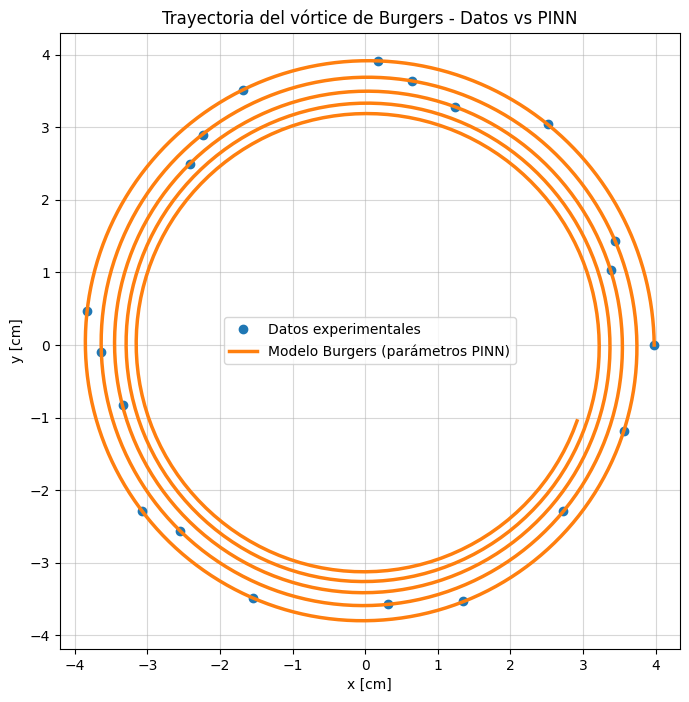

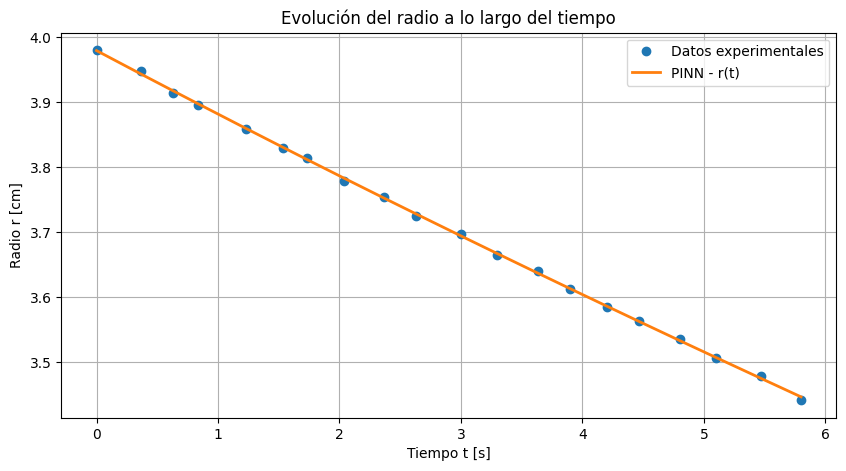

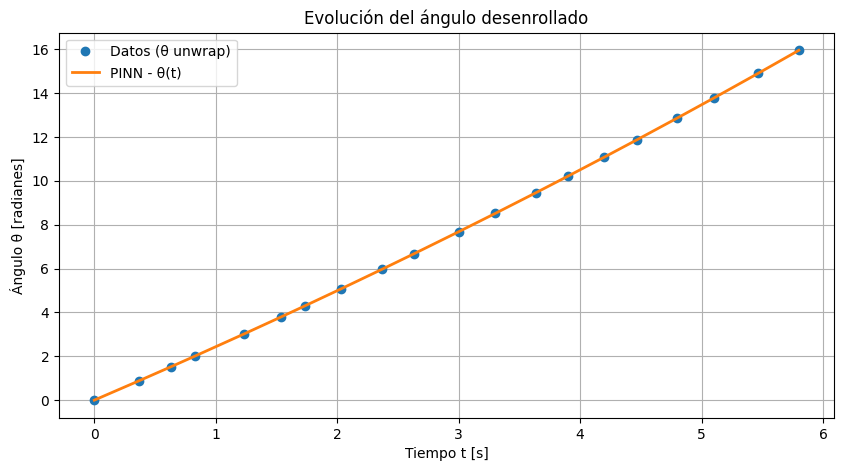

Visualización completada.
Parámetros finales usados: α = 0.04314, Γ = 411.0, r0 = 0.6000


In [8]:

# ====================== ANÁLISIS Y VISUALIZACIÓN CON PARÁMETROS PINN ======================

print("\n=== ANÁLISIS VISUAL CON PARÁMETROS APRENDIDOS ===")

alpha = model.alpha.item()
Gamma = torch.exp(model.log_Gamma).item()
r0 = model.r0.item()

# Simulación Euler para extrapolar la trayectoria
t_sim = np.linspace(t_data_np[0], t_data_np[-1], 800)
dt = t_sim[1] - t_sim[0]

r_sim = np.zeros_like(t_sim)
theta_sim = np.zeros_like(t_sim)

r_sim[0] = r_data[0]
theta_sim[0] = theta_unwrapped[0]

for i in range(len(t_sim)-1):
    r = max(r_sim[i], 1e-6)
    drdt = -alpha * r
    dthetadt = (Gamma / (2 * np.pi * r**2)) * (1 - np.exp(-(r**2) / r0**2))

    r_sim[i+1] = r + drdt * dt
    theta_sim[i+1] = theta_sim[i] + dthetadt * dt

x_sim = r_sim * np.cos(theta_sim)
y_sim = r_sim * np.sin(theta_sim)

# Gráfico 1: Trayectoria espiral en el plano x-y
plt.figure(figsize=(8, 8))
plt.plot(x_data, y_data, 'o', markersize=6, label="Datos experimentales")
plt.plot(x_sim, y_sim, '-', linewidth=2.5, label="Modelo Burgers (parámetros PINN)")
plt.axis('equal')
plt.grid(True, alpha=0.5)
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Trayectoria del vórtice de Burgers - Datos vs PINN")
plt.legend()
plt.show()

# Gráfico 2: Evolución del radio r(t)
with torch.no_grad():
    pred_norm = model.forward(t_norm)
    r_pred = (pred_norm[:, 0].numpy() * r_std + r_mean)

plt.figure(figsize=(10, 5))
plt.plot(t_data_np, r_data, 'o', label="Datos experimentales")
plt.plot(t_data_np, r_pred, '-', linewidth=2, label="PINN - r(t)")
plt.xlabel("Tiempo t [s]")
plt.ylabel("Radio r [cm]")
plt.grid(True)
plt.legend()
plt.title("Evolución del radio a lo largo del tiempo")
plt.show()

# Gráfico 3: Evolución del ángulo θ(t) desenrollado
with torch.no_grad():
    theta_pred_norm = model.forward(t_norm)[:, 1].numpy()
    theta_pred = theta_pred_norm * theta_std + theta_mean

plt.figure(figsize=(10, 5))
plt.plot(t_data_np, theta_unwrapped, 'o', label="Datos (θ unwrap)")
plt.plot(t_data_np, theta_pred, '-', linewidth=2, label="PINN - θ(t)")
plt.xlabel("Tiempo t [s]")
plt.ylabel("Ángulo θ [radianes]")
plt.grid(True)
plt.legend()
plt.title("Evolución del ángulo desenrollado")
plt.show()

print("Visualización completada.")
print(f"Parámetros finales usados: α = {alpha:.5f}, Γ = {Gamma:.1f}, r0 = {r0:.4f}")

Se puede observar a simple vista una espiral como se nos pedia en el ejercicio. Para confirmar esto podemos ver como se relacionan las coordenadas $r$ y $\theta$ y se puede ver que se relacionan mediante una ecuacion lineal, la cual corresponde a la ecuacion de una esprial.